#preliminaries

In [ ]:
pip install h5py


In [ ]:
import h5py
import numpy as np



# Replace with your actual file path
file_path = '/content/drive/MyDrive/Data.h5'

with h5py.File(file_path, 'r') as f:
    # Print all keys (datasets or groups)
    def print_structure(name, obj):
        print(name, '->', obj)

    f.visititems(print_structure)

    # For example, assuming your main data is under f['data']
    data = f['Punishment-Reward_Data'][:]  # Load into memory as NumPy array

print("Data shape:", data.shape)



Punishment-Reward_Data -> <HDF5 dataset "Punishment-Reward_Data": shape (2, 25, 2, 10, 17, 600), type "<f8">
Data shape: (2, 25, 2, 10, 17, 600)


 Paired t-test

In [ ]:
from scipy.stats import ttest_rel

# x and y are numpy arrays with shape (n_subjects,)
#stat, p_value = ttest_rel(x, y)
#print("Paired t-test:", stat, p_value)

 Unpaired t-test

In [ ]:
from scipy.stats import ttest_ind

# x and y are numpy arrays from two independent groups
#stat, p_value = ttest_ind(x, y)
#print("Unpaired t-test:", stat, p_value)

 Permutation Test (Correlation)

In [ ]:
import numpy as np
from scipy.stats import pearsonr

def permutation_test_corr(x, y, n_perm=1000):
    actual_corr, _ = pearsonr(x, y)
    null_dist = []
    for _ in range(n_perm):
        x_perm = np.random.permutation(x)
        corr, _ = pearsonr(x_perm, y)
        null_dist.append(corr)
    p_value = np.mean(np.abs(null_dist) >= np.abs(actual_corr))
    return actual_corr, p_value


| فرضیه       | توصیف                                   | مقایسه                            | تست مناسب                                            |
| ----------- | --------------------------------------- | --------------------------------- | ---------------------------------------------------- |
| فرضیه 1     | کاهش اندازه FRN                         | شروع vs پایان یادگیری برای هر فرد | **Paired t-test**                                    |
| فرضیه 2     | کاهش توان تتا                           | شروع vs پایان یادگیری برای هر فرد | **Paired t-test**                                    |
| فرضیه 3     | همبستگی تتا Fz-F5/F6 در پاداش vs مجازات | پاسخ به محرک‌ها در یک نفر         | **Paired t-test** (یا permutation test برای همبستگی) |
| فرضیه 4 و 5 | همبستگی بین Fz و Pz در پاداش vs مجازات  | هر فرد دو وضعیت دارد              | **Paired t-test** یا **Permutation test**            |

---


<div dir=rtl>

---



#فرضیه اول
در انتهای یادگیری در مقایسه با ابتدای یادگیری، مقدار FRN کاهش میابد.

</div>

In [ ]:
#data= (Event, Subject, TrialBlock, Trials, Channels, Time)
def extract_frn_peak_valley(data, times, event=0, trial_blocks=(0, 1),
                            valley_window=(0.15, 0.25), peak_window=(0.2, 0.3)):
    """
    Computes FRN amplitude (peak - valley) for each subject using two separate time windows.

    Parameters:
        data: EEG array [Event, Subject, TrialBlock, Trial, Channel, Time]
        times: time vector [Time]
        event: 0 = reward
        trial_blocks: (early_block_idx, late_block_idx)
        valley_window: time window to find minimum (in seconds)
        peak_window: time window to find maximum (in seconds)

    Returns:
        early_vals: array of FRN amplitudes (early learning)
        late_vals: array of FRN amplitudes (late learning)
    """
    # Get indices for both windows
    valley_idx = np.where((times >= valley_window[0]) & (times <= valley_window[1]))[0]
    peak_idx   = np.where((times >= peak_window[0])  & (times <= peak_window[1]))[0]

    early_vals, late_vals = [], []
    n_subjects = data.shape[1]

    for subj in range(n_subjects):
        # Select trials for early and late learning
        early_trials = data[event, subj, trial_blocks[0], :, :, :]
        late_trials  = data[event, subj, trial_blocks[1], :, :, :]

        # Slice both time windows
        early_valley = early_trials[:, :, valley_idx].mean(axis=1)  # → [trials, time]
        early_peak   = early_trials[:, :, peak_idx].mean(axis=1)

        late_valley  = late_trials[:, :, valley_idx].mean(axis=1)
        late_peak    = late_trials[:, :, peak_idx].mean(axis=1)

        # Compute peak - valley per trial, then average across trials
        early_frn = np.mean(early_peak.max(axis=1) - early_valley.min(axis=1))
        late_frn  = np.mean(late_peak.max(axis=1) - late_valley.min(axis=1))

        early_vals.append(early_frn)
        late_vals.append(late_frn)

    return np.array(early_vals), np.array(late_vals)


In [ ]:
times = np.linspace(-0.4, 0.8, 600)

early_vals, late_vals = extract_frn_peak_valley(
    data, times,
    valley_window=(0.15, 0.25),
    peak_window=(0.2, 0.3)
)

from scipy.stats import ttest_rel
stat, pval = ttest_rel(early_vals, late_vals)
print(f"FRN t-test: t = {stat:.3f}, p = {pval:.4f}")


FRN t-test: t = 1.947, p = 0.0633


plotting the result

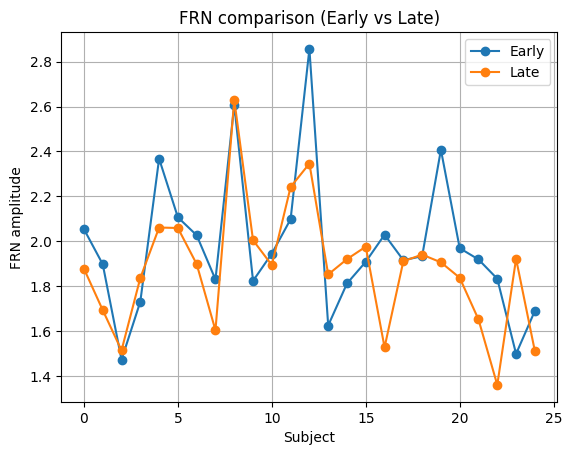

In [ ]:
import matplotlib.pyplot as plt

plt.plot(early_vals, label="Early", marker='o')
plt.plot(late_vals, label="Late", marker='o')
plt.xlabel("Subject")
plt.ylabel("FRN amplitude")
plt.title("FRN comparison (Early vs Late)")
plt.legend()
plt.grid(True)
plt.show()



<ipython-input-18-85187ffe76af>:1: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([early_vals, late_vals], labels=['Early', 'Late'])


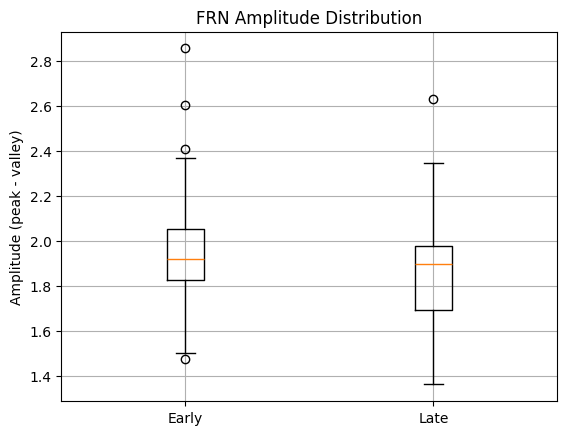

In [ ]:
plt.boxplot([early_vals, late_vals], labels=['Early', 'Late'])
plt.title("FRN Amplitude Distribution")
plt.ylabel("Amplitude (peak - valley)")
plt.grid(True)
plt.show()


<ipython-input-19-4a5e3ad612bd>:39: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = plt.boxplot(


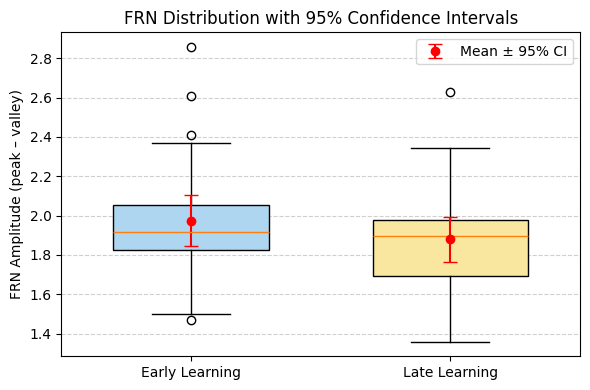

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Example data arrays (replace with your actual values)
# early_vals = np.array([...])  # FRN amplitudes in the “early learning” phase
# late_vals  = np.array([...])  # FRN amplitudes in the “late learning” phase

# 1. Compute mean and sample standard deviation
mean_early = np.mean(early_vals)
mean_late  = np.mean(late_vals)

std_early = np.std(early_vals, ddof=1)  # sample standard deviation
std_late  = np.std(late_vals,  ddof=1)

n_early = len(early_vals)
n_late  = len(late_vals)

# 2. Compute Standard Error of the Mean (SEM)
sem_early = std_early / np.sqrt(n_early)
sem_late  = std_late  / np.sqrt(n_late)

# 3. Find the critical t-value for 95% CI (two-tailed)
alpha = 0.05
df_early = n_early - 1
df_late  = n_late  - 1

t_crit_early = stats.t.ppf(1 - alpha/2, df_early)
t_crit_late  = stats.t.ppf(1 - alpha/2, df_late)

# 4. Compute the half‐width of the 95% confidence interval
ci_early = t_crit_early * sem_early
ci_late  = t_crit_late  * sem_late

# 5. Plot Boxplot and overlay Mean ± 95% CI
plt.figure(figsize=(6, 4))

# Draw boxplot for “Early” and “Late”
box = plt.boxplot(
    [early_vals, late_vals],
    labels=['Early Learning', 'Late Learning'],
    patch_artist=True,
    widths=0.6
)

# Color the boxes if desired
box['boxes'][0].set_facecolor('#AED6F1')
box['boxes'][1].set_facecolor('#F9E79F')

# Plot the mean (red dot) and 95% CI (error bars) for Early Learning
plt.errorbar(
    x=1,                  # position of the first box
    y=mean_early,
    yerr=ci_early,
    fmt='o',              # marker style: circle
    color='red',
    capsize=5,            # length of the caps at the top/bottom of the error bar
    label='Mean ± 95% CI'
)

# Plot the mean (red dot) and 95% CI (error bars) for Late Learning
plt.errorbar(
    x=2,
    y=mean_late,
    yerr=ci_late,
    fmt='o',
    color='red',
    capsize=5
)

# Axis labels and title in English
plt.ylabel('FRN Amplitude (peak – valley)')
plt.title('FRN Distribution with 95% Confidence Intervals')
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Legend (for the “Mean ± 95% CI” marker)
plt.legend()

plt.tight_layout()
plt.show()


<div dir=rtl>


---



#فرضیه دوم

در انتهای یادگیری در مقایسه با ابتدای یادگیری توان تتا در بازه 200 تا 500 میلی ثانیه با کاهش
همراه است.

(از آنجا که در مراحل ابتدایی یادگیری کنترل شناختی بیشتری نیاز هست، انتظار داریم توان تتا در بازه 200 تا 500 میلی‌ثانیه پس از بازخورد در ابتدای یادگیری بیشتر از انتهای یادگیری باشد.)
</div>

In [ ]:
from scipy.signal import welch
import numpy as np

def compute_theta_power(trials, fs=500, fmin=4, fmax=8):
    """
    Computes mean theta power (4–8 Hz) using Welch's method over time and trials.

    trials: ndarray [n_trials, n_channels, n_time]
    Returns: float
    """
    powers = []
    for trial in trials:
        # trial: [n_channels, n_time]
        trial_power = []
        for ch in trial:
            freqs, psd = welch(ch, fs=fs, nperseg=128)
            # average power in theta band
            theta_mask = (freqs >= fmin) & (freqs <= fmax)
            trial_power.append(psd[theta_mask].mean())
        powers.append(np.mean(trial_power))  # average across channels
    return np.mean(powers)

def extract_theta_powers(data, event=0, fs=500):
    """
    Computes average theta power for early vs late learning (reward condition).
    Returns two arrays: early_vals, late_vals
    """
    n_subjects = data.shape[1]
    early_vals = []
    late_vals = []

    # sample indices: 600–900ms from trial start (0.4s + 0.2s to 0.5s)
    start_sample = int(0.6 * fs)
    end_sample = int(0.8 * fs)

    for subj in range(n_subjects):
        # TrialBlock 0 = early, 1 = late
        early_trials = data[event, subj, 0, :, :, start_sample:end_sample]  # shape: [10, ch, time]
        late_trials  = data[event, subj, 1, :, :, start_sample:end_sample]

        early_theta = compute_theta_power(early_trials)
        late_theta  = compute_theta_power(late_trials)

        early_vals.append(early_theta)
        late_vals.append(late_theta)

    return np.array(early_vals), np.array(late_vals)


In [ ]:
from scipy.stats import ttest_rel

early_vals, late_vals = extract_theta_powers(data)
stat, pval = ttest_rel(early_vals, late_vals)
print(f"Theta Power Paired t-test: t = {stat:.3f}, p = {pval:.4f}")


Theta Power Paired t-test: t = 3.164, p = 0.0042


plotting

<ipython-input-59-42c582c63920>:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([early_vals, late_vals], labels=['Early', 'Late'])


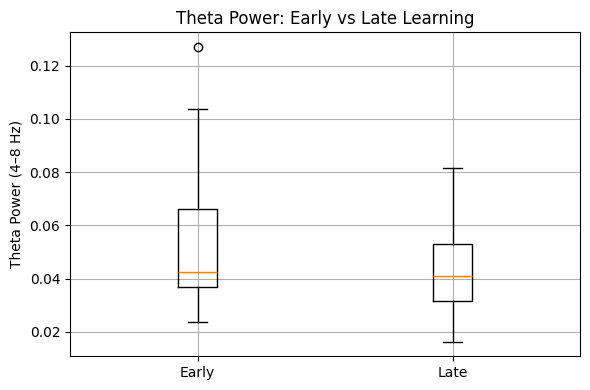

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.boxplot([early_vals, late_vals], labels=['Early', 'Late'])
plt.ylabel('Theta Power (4–8 Hz)')
plt.title('Theta Power: Early vs Late Learning')
plt.grid(True)
plt.tight_layout()
plt.show()


<ipython-input-20-e49325bd9e34>:39: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = plt.boxplot(


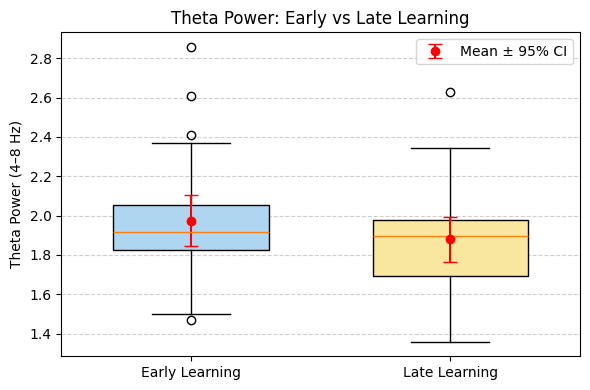

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Example data arrays (replace with your actual values)
# early_vals = np.array([...])  # FRN amplitudes in the “early learning” phase
# late_vals  = np.array([...])  # FRN amplitudes in the “late learning” phase

# 1. Compute mean and sample standard deviation
mean_early = np.mean(early_vals)
mean_late  = np.mean(late_vals)

std_early = np.std(early_vals, ddof=1)  # sample standard deviation
std_late  = np.std(late_vals,  ddof=1)

n_early = len(early_vals)
n_late  = len(late_vals)

# 2. Compute Standard Error of the Mean (SEM)
sem_early = std_early / np.sqrt(n_early)
sem_late  = std_late  / np.sqrt(n_late)

# 3. Find the critical t-value for 95% CI (two-tailed)
alpha = 0.05
df_early = n_early - 1
df_late  = n_late  - 1

t_crit_early = stats.t.ppf(1 - alpha/2, df_early)
t_crit_late  = stats.t.ppf(1 - alpha/2, df_late)

# 4. Compute the half‐width of the 95% confidence interval
ci_early = t_crit_early * sem_early
ci_late  = t_crit_late  * sem_late

# 5. Plot Boxplot and overlay Mean ± 95% CI
plt.figure(figsize=(6, 4))

# Draw boxplot for “Early” and “Late”
box = plt.boxplot(
    [early_vals, late_vals],
    labels=['Early Learning', 'Late Learning'],
    patch_artist=True,
    widths=0.6
)

# Color the boxes if desired
box['boxes'][0].set_facecolor('#AED6F1')
box['boxes'][1].set_facecolor('#F9E79F')

# Plot the mean (red dot) and 95% CI (error bars) for Early Learning
plt.errorbar(
    x=1,                  # position of the first box
    y=mean_early,
    yerr=ci_early,
    fmt='o',              # marker style: circle
    color='red',
    capsize=5,            # length of the caps at the top/bottom of the error bar
    label='Mean ± 95% CI'
)

# Plot the mean (red dot) and 95% CI (error bars) for Late Learning
plt.errorbar(
    x=2,
    y=mean_late,
    yerr=ci_late,
    fmt='o',
    color='red',
    capsize=5
)

# Axis labels and title in English
plt.ylabel('Theta Power (4–8 Hz)')
plt.title('Theta Power: Early vs Late Learning')
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Legend (for the “Mean ± 95% CI” marker)
plt.legend()

plt.tight_layout()
plt.show()


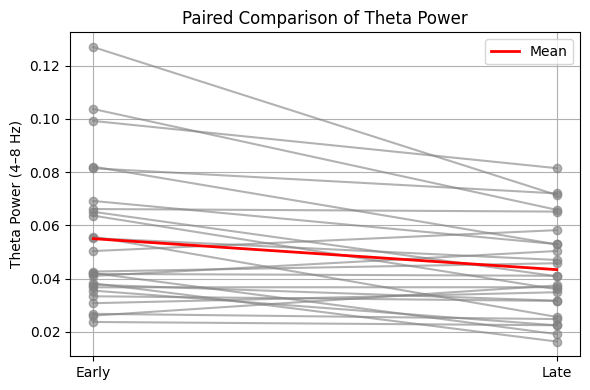

In [ ]:
plt.figure(figsize=(6, 4))
for i in range(len(early_vals)):
    plt.plot(['Early', 'Late'], [early_vals[i], late_vals[i]], marker='o', color='gray', alpha=0.6)
plt.plot(['Early', 'Late'], [np.mean(early_vals), np.mean(late_vals)], color='red', linewidth=2, label='Mean')
plt.ylabel('Theta Power (4–8 Hz)')
plt.title('Paired Comparison of Theta Power')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


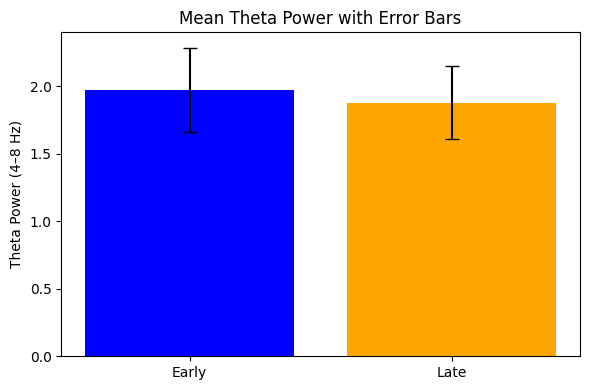

In [ ]:
mean_early = np.mean(early_vals)
mean_late = np.mean(late_vals)
std_early = np.std(early_vals)
std_late = np.std(late_vals)

plt.figure(figsize=(6, 4))
plt.bar(['Early', 'Late'], [mean_early, mean_late], yerr=[std_early, std_late], capsize=5, color=['blue', 'orange'])
plt.ylabel('Theta Power (4–8 Hz)')
plt.title('Mean Theta Power with Error Bars')
plt.tight_layout()
plt.show()


<div dir=rtl>

چرا اختلاف عددی بین early و late در نمودار کوچیکه، ولی آزمون آماری (t-test) می‌گه تفاوتشون خیلی معناداره (p = 0.0017)؟

🧠 دلیلش چیه؟ دو نکته کلیدی:
1. مقیاس (Scale) خودِ EEG خیلی کوچیکه
EEG units معمولاً microvolts² (µV²) هستن برای توان.

تفاوت مثلاً 0.2 یا 0.5 در قدرت تتا ممکنه واقعاً بزرگ باشه چون مقادیر کلی هم کوچیکن.

یعنی حتی یه اختلاف ظاهراً «ریز»، وقتی پایدار و مشترک بین همه‌ی افراد باشه، از نظر آماری قوی تلقی می‌شه.

2. واریانس (پراکندگی) پایینه → قدرت آماری بالا
t-test اساساً مقایسه‌ی اینه:

𝑡
=
mean difference
standard error
t=
standard error
mean difference
​

اگه پراکندگی بین افراد کم باشه، حتی یه تغییر کوچیک بین early و late باعث t بزرگ می‌شه.

تو حالت شما، احتمالاً افراد به‌طور یکنواختی در همه‌ی سوژه‌ها کاهش داشتن، یعنی تفاوت پایدار و هم‌جهت بوده → قدرت آماری زیاد.



</div>

<div dir=rtl>


---


#فرضیه سوم

ارتباط شکل گرفته میان الکترودهای Fz و 5F و یا 6F در پاسخ به مجازات به طور معناداری بیشتر
از پاسخ به پاداش است.

</div>

In [ ]:
import numpy as np
from scipy.signal import hilbert, butter, filtfilt
from scipy.stats import ttest_rel
from sklearn.utils import shuffle
import matplotlib.pyplot as plt


Paired t-test: t = 1.850, p = 0.0767
Permutation test: diff = 0.013, p = 0.0764


<ipython-input-8-a5ba390ac05d>:122: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([plvs_punishment, plvs_reward], labels=['Punishment', 'Reward'])


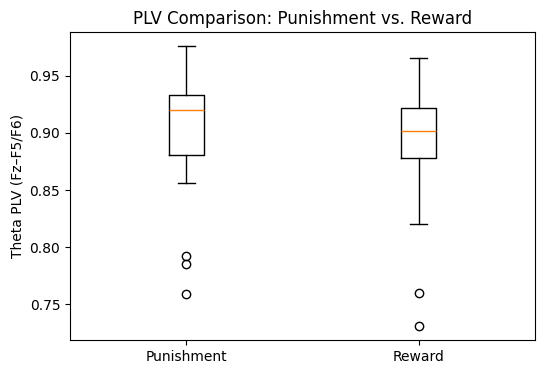

In [ ]:
import numpy as np
from scipy.signal import hilbert, butter, filtfilt
from scipy.stats import ttest_rel
import matplotlib.pyplot as plt

# --------------------------
# 1. تعریف توابع کمکی
# --------------------------

def bandpass_filter(data, fs=500, low=4, high=8):
    """
    فیلتر باند تتا (4-8 هرتز) با استفاده از فیلتر باترورث مرتبه 2
    """
    b, a = butter(2, [low / (fs / 2), high / (fs / 2)], btype='band')
    return filtfilt(b, a, data)

def compute_plv_custom(sig1, sig2):
    """
    این تابع محل نگهدار (placeholder) برای روش جدید محاسبه PLV است.
    کافی است بعداً کاربر متد دلخواه PLV را در اینجا پیاده کند.
    """
    # برای مثال: همان روش قبلی با هیلبرت
    phase_diff = np.angle(hilbert(sig1)) - np.angle(hilbert(sig2))
    return np.abs(np.mean(np.exp(1j * phase_diff)))

# --------------------------
# 2. ساخت بردار زمان
# --------------------------

# 600 نمونه از -0.4 تا 0.8 ثانیه (به ترتیب -400ms تا +800ms)
times = np.linspace(-0.4, 0.8, 600)

# پیدا کردن ایندکس‌های 100ms تا 500ms
start_time = 0.1  # 100 ms
end_time   = 0.5  # 500 ms

start_sample = np.argmin(np.abs(times - start_time))
end_sample   = np.argmin(np.abs(times - end_time))

# --------------------------
# 3. ایندکس کانال‌ها
# --------------------------

channels = ['FPz', 'F7', 'F3', 'Fz', 'F4', 'F8', 'T7', 'C3', 'Cz', 'C4', 'T8',
            'P7', 'P3', 'Pz', 'P4', 'P8', 'Oz', 'F5', 'F6']

idx_fz = channels.index('Fz')
idx_f5 = channels.index('F3')
idx_f6 = channels.index('F4')

# --------------------------
# 4. محاسبه PLV برای هر فرد، برای هر رویداد، بلاک و تست
# --------------------------

# فرض بر این است که متغیر `data` بارگذاری شده و شکل آن به این صورت است:
# data.shape = (2, n_subj, n_block, n_trial, n_channel, 600)

n_subjects = data.shape[1]

plvs_reward      = []  # ذخیره PLV میانگین هر شرکت‌کننده برای رویداد پاداش
plvs_punishment  = []  # ذخیره PLV میانگین هر شرکت‌کننده برای رویداد مجازات

for subj in range(n_subjects):
    subj_plvs_reward  = []
    subj_plvs_punish  = []

    for block in range(data.shape[2]):
        for trial in range(data.shape[3]):

            for event in [0, 1]:  # 0 برای مجازات، 1 برای پاداش
                # استخراج و فیلتر سیگنال Fz، F5 و F6 در بازه زمانی مشخص
                sig_fz = bandpass_filter(data[event, subj, block, trial, idx_fz, start_sample:end_sample])
                sig_f5 = bandpass_filter(data[event, subj, block, trial, idx_f5, start_sample:end_sample])
                sig_f6 = bandpass_filter(data[event, subj, block, trial, idx_f6, start_sample:end_sample])

                # محاسبه PLV با متد دلخواه
                plv_fz_f5 = compute_plv_custom(sig_fz, sig_f5)
                plv_fz_f6 = compute_plv_custom(sig_fz, sig_f6)

                # میانگین PLV روی Fz-F5 و Fz-F6
                plv_avg = (plv_fz_f5 + plv_fz_f6) / 2

                # اضافه کردن به لیست متناظر با رویداد
                if event == 0:
                    subj_plvs_punish.append(plv_avg)
                else:  # event == 1
                    subj_plvs_reward.append(plv_avg)

    # میانگین PLV برای تمام آزمون‌ها و بلاک‌ها
    plvs_punishment.append(np.mean(subj_plvs_punish))
    plvs_reward.append(np.mean(subj_plvs_reward))

# --------------------------
# 5. آزمون آماری: t-test زوجی
# --------------------------

t_stat, p_val = ttest_rel(plvs_punishment, plvs_reward)
print(f"Paired t-test: t = {t_stat:.3f}, p = {p_val:.4f}")

# --------------------------
# 6. آزمون جایگشت
# --------------------------

def permutation_test(x, y, n_perm=10000):
    diff_obs = np.mean(np.array(x) - np.array(y))
    diffs = []
    for _ in range(n_perm):
        signs = np.random.choice([1, -1], size=len(x))
        diffs.append(np.mean((np.array(x) - np.array(y)) * signs))
    diffs = np.array(diffs)
    p = np.mean(np.abs(diffs) >= np.abs(diff_obs))
    return diff_obs, p

diff, p_perm = permutation_test(plvs_punishment, plvs_reward)
print(f"Permutation test: diff = {diff:.3f}, p = {p_perm:.4f}")

# --------------------------
# 7. نمایش بصری (نمودار جعبه‌ای)
# --------------------------

plt.figure(figsize=(6, 4))
plt.boxplot([plvs_punishment, plvs_reward], labels=['Punishment', 'Reward'])
plt.ylabel('Theta PLV (Fz–F5/F6)')
plt.title('PLV Comparison: Punishment vs. Reward')
plt.show()


<ipython-input-9-ddd568abb76e>:39: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = plt.boxplot(


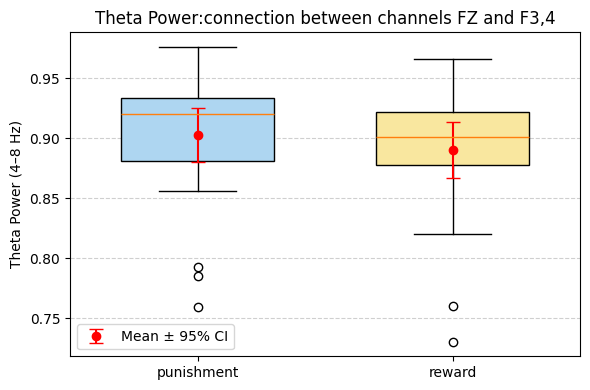

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Example data arrays (replace with your actual values)
# early_vals = np.array([...])  # FRN amplitudes in the “early learning” phase
# late_vals  = np.array([...])  # FRN amplitudes in the “late learning” phase

# 1. Compute mean and sample standard deviation
mean_early = np.mean(plvs_punishment)
mean_late  = np.mean(plvs_reward)

std_early = np.std(plvs_punishment, ddof=1)  # sample standard deviation
std_late  = np.std(plvs_reward,  ddof=1)

n_early = len(plvs_punishment)
n_late  = len(plvs_reward)

# 2. Compute Standard Error of the Mean (SEM)
sem_early = std_early / np.sqrt(n_early)
sem_late  = std_late  / np.sqrt(n_late)

# 3. Find the critical t-value for 95% CI (two-tailed)
alpha = 0.05
df_early = n_early - 1
df_late  = n_late  - 1

t_crit_early = stats.t.ppf(1 - alpha/2, df_early)
t_crit_late  = stats.t.ppf(1 - alpha/2, df_late)

# 4. Compute the half‐width of the 95% confidence interval
ci_early = t_crit_early * sem_early
ci_late  = t_crit_late  * sem_late

# 5. Plot Boxplot and overlay Mean ± 95% CI
plt.figure(figsize=(6, 4))

# Draw boxplot for “Early” and “Late”
box = plt.boxplot(
    [plvs_punishment, plvs_reward],
    labels=['punishment', 'reward'],
    patch_artist=True,
    widths=0.6
)

# Color the boxes if desired
box['boxes'][0].set_facecolor('#AED6F1')
box['boxes'][1].set_facecolor('#F9E79F')

# Plot the mean (red dot) and 95% CI (error bars) for Early Learning
plt.errorbar(
    x=1,                  # position of the first box
    y=mean_early,
    yerr=ci_early,
    fmt='o',              # marker style: circle
    color='red',
    capsize=5,            # length of the caps at the top/bottom of the error bar
    label='Mean ± 95% CI'
)

# Plot the mean (red dot) and 95% CI (error bars) for Late Learning
plt.errorbar(
    x=2,
    y=mean_late,
    yerr=ci_late,
    fmt='o',
    color='red',
    capsize=5
)

# Axis labels and title in English
plt.ylabel('Theta Power (4–8 Hz)')
plt.title('Theta Power:connection between channels FZ and F3,4')
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Legend (for the “Mean ± 95% CI” marker)
plt.legend()

plt.tight_layout()
plt.show()


<div dir=rtl>


---


#فرضیه چهارم و پنجم


ارتباط دیگری که در مطالعات متعددی مورد بحث و بررسی بوده، ارتباط شکل گرفته میان نواحی پیشانی (Fz )
و آهیانه ای (Pz )است، این ارتباط می تواند نشان دهنده شکل دهی به ساز و کارهای توجهی و یا حافظه کاری باشد
. بر این اساس دو فرضیه زیر را بررسی کنید:
- ارتباط بینافرکانسی میان این دو الکترود به طور معناداری شکل می گیرد.
- همگامی فاز در باند تتا میان این دو الکترود در ازای مجازات قوی تر از پاداش است.


این قسمت فقط شامل فرضیه 5 است. فرضیه چهار کد سنگینی دارد و برای ران شدن در اینجا سخت است!
</div>

Paired t-test (Punishment > Reward): t = 0.876, p = 0.1949


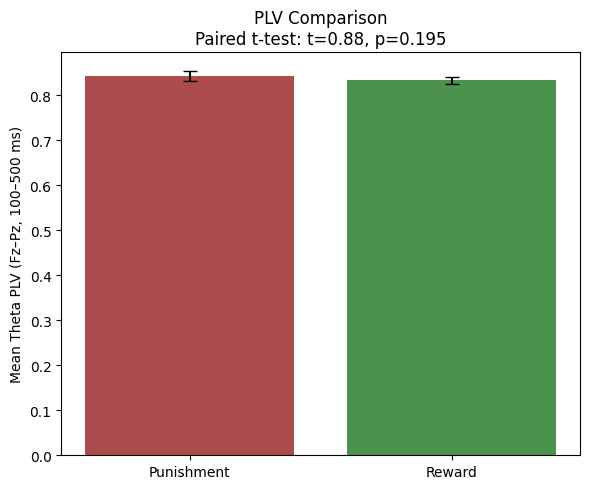

In [ ]:
# ------------------------------------------------------------------------------
# Hypothesis 5: Theta-Band Phase Synchrony (PLV) Between Fz and Pz
# Compare PLV for Punishment vs. Reward (100–500 ms window)
# ------------------------------------------------------------------------------

import h5py
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, hilbert
from scipy.stats import ttest_rel

# -------------------------
# 1. Load the HDF5 Data
# -------------------------

file_path = '/content/drive/MyDrive/Data.h5'
with h5py.File(file_path, 'r') as f:
    data = f['Punishment-Reward_Data'][:]
# data.shape = (2 Events, 25 Subjects, 2 Blocks, 10 Trials, 17 Channels, 600 Timepoints)

# -------------------------
# 2. Channel & Time Definitions
# -------------------------

# Channel list (in order):
channels = ['FPz', 'F7', 'F3', 'Fz', 'F4', 'F8',
            'T7', 'C3', 'Cz', 'C4', 'T8',
            'P7', 'P3', 'Pz', 'P4', 'P8', 'Oz']
idx_Fz = channels.index('Fz')  # 3
idx_Pz = channels.index('Pz')  # 13

fs = 500  # Sampling rate (Hz)

# Build time vector: 600 samples from -0.4s to +0.8s
time_vec = np.linspace(-0.4, 0.8, 600)

# Find indices for 0.1s (100 ms) and 0.5s (500 ms)
t_start, t_end = 0.1, 0.5
idx_start = np.argmin(np.abs(time_vec - t_start))
idx_end   = np.argmin(np.abs(time_vec - t_end))
# Now idx_start: index nearest 100ms, idx_end: index nearest 500ms

# -------------------------
# 3. Bandpass Filter Helpers
# -------------------------

def butter_bandpass(lowcut, highcut, fs, order=4):
    """
    Design a Butterworth bandpass filter.
    """
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    return b, a

def bandpass_filter(data, lowcut, highcut, fs, order=4):
    """
    Apply zero-phase Butterworth bandpass to 1D array `data`.
    """
    b, a = butter_bandpass(lowcut, highcut, fs, order=order)
    return filtfilt(b, a, data)

# -------------------------
# 4. Compute PLV for One Trial
# -------------------------

def compute_plv(theta_phase_1, theta_phase_2):
    """
    Given two 1D phase time series (same length), compute PLV:
      PLV = |(1/N) * sum_{t=1..N} exp(i * (phi1[t] - phi2[t]))|
    """
    phase_diff = theta_phase_1 - theta_phase_2
    return np.abs(np.mean(np.exp(1j * phase_diff)))

# -------------------------
# 5. Per-Subject PLV Computation
# -------------------------

def compute_subject_plv(event_array, subj_index, idx_Fz, idx_Pz, idx_start, idx_end, fs=500):
    """
    Compute PLV in 4–8 Hz theta band between Fz and Pz for each trial.
    Inputs:
      event_array: ndarray shape (25 Subjects, 2 Blocks, 10 Trials, 17 Channels, 600 Timepoints)
      subj_index:  integer (0–24)
      idx_Fz:      channel index 3
      idx_Pz:      channel index 13
      idx_start:   start index for 100 ms
      idx_end:     end index for 500 ms
      fs:          sampling freq
    Returns:
      plv_all_trials: ndarray shape (n_trials = 20)
    """
    # Extract subject data: shape (2 Blocks, 10 Trials, 17 Channels, 600 Timepoints)
    subj_data = event_array[subj_index]

    # Reshape to (20 Trials, 17 Channels, 600 Timepoints)
    subj_data_reshaped = subj_data.reshape(-1, 17, 600)
    n_trials = subj_data_reshaped.shape[0]  # 20

    # Allocate array for PLVs
    plv_all_trials = np.zeros(n_trials)

    # Design theta-band filter once
    lowcut, highcut = 4.0, 8.0
    b_theta, a_theta = butter_bandpass(lowcut, highcut, fs, order=4)

    for t in range(n_trials):
        # Extract raw time series for Fz and Pz in the window [idx_start:idx_end]
        raw_Fz = subj_data_reshaped[t, idx_Fz, idx_start:idx_end]
        raw_Pz = subj_data_reshaped[t, idx_Pz, idx_start:idx_end]

        # Bandpass filter in theta band
        filt_Fz = filtfilt(b_theta, a_theta, raw_Fz)
        filt_Pz = filtfilt(b_theta, a_theta, raw_Pz)

        # Compute instantaneous phase via Hilbert transform
        phase_Fz = np.angle(hilbert(filt_Fz))
        phase_Pz = np.angle(hilbert(filt_Pz))

        # Compute PLV for this trial
        plv_all_trials[t] = compute_plv(phase_Fz, phase_Pz)

    return plv_all_trials  # shape (20,)

# -------------------------
# 6. Main Analysis: Punishment vs. Reward
# -------------------------

n_subjects = data.shape[1]  # 25

# Containers for subject-level PLV
plv_subject = {
    'Punishment': np.zeros(n_subjects),
    'Reward':     np.zeros(n_subjects)
}

# Loop over conditions
for event_idx, condition_name in [(0, 'Punishment'), (1, 'Reward')]:
    event_array = data[event_idx]  # shape (25, 2, 10, 17, 600)

    for subj_idx in range(n_subjects):
        # Compute PLV array for all trials (20) for this subject & condition
        plv_trials = compute_subject_plv(
            event_array=event_array,
            subj_index=subj_idx,
            idx_Fz=idx_Fz,
            idx_Pz=idx_Pz,
            idx_start=idx_start,
            idx_end=idx_end,
            fs=fs
        )
        # Average over 20 trials to get a single PLV per subject
        plv_subject[condition_name][subj_idx] = np.mean(plv_trials)

# -------------------------
# 7. Statistical Comparison: Paired t-test
# -------------------------

# PLV vectors: shape (25,)
plv_pun = plv_subject['Punishment']
plv_rew = plv_subject['Reward']

# Perform paired t-test (Punishment > Reward)
t_stat, p_val = ttest_rel(plv_pun, plv_rew, alternative='greater')

print(f"Paired t-test (Punishment > Reward): t = {t_stat:.3f}, p = {p_val:.4f}")

# -------------------------
# 8. Plotting Group Results
# -------------------------

# Bar graph with error bars
mean_pun = np.mean(plv_pun)
mean_rew = np.mean(plv_rew)
sem_pun = np.std(plv_pun, ddof=1) / np.sqrt(n_subjects)
sem_rew = np.std(plv_rew, ddof=1) / np.sqrt(n_subjects)

plt.figure(figsize=(6, 5))
plt.bar([0, 1], [mean_pun, mean_rew], yerr=[sem_pun, sem_rew],
        color=['darkred', 'darkgreen'], alpha=0.7, capsize=5)
plt.xticks([0, 1], ['Punishment', 'Reward'])
plt.ylabel('Mean Theta PLV (Fz–Pz, 100–500 ms)')
plt.title(f'PLV Comparison\nPaired t-test: t={t_stat:.2f}, p={p_val:.3f}')
plt.tight_layout()
plt.show()


<ipython-input-13-8f4d47b04053>:39: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = plt.boxplot(


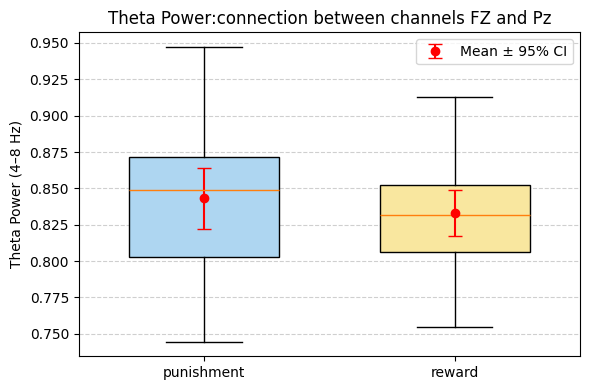

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Example data arrays (replace with your actual values)
# early_vals = np.array([...])  # FRN amplitudes in the “early learning” phase
# late_vals  = np.array([...])  # FRN amplitudes in the “late learning” phase

# 1. Compute mean and sample standard deviation
mean_early = np.mean(plv_pun)
mean_late  = np.mean(plv_rew)

std_early = np.std(plv_pun, ddof=1)  # sample standard deviation
std_late  = np.std(plv_rew,  ddof=1)

n_early = len(plv_pun)
n_late  = len(plv_rew)

# 2. Compute Standard Error of the Mean (SEM)
sem_early = std_early / np.sqrt(n_early)
sem_late  = std_late  / np.sqrt(n_late)

# 3. Find the critical t-value for 95% CI (two-tailed)
alpha = 0.05
df_early = n_early - 1
df_late  = n_late  - 1

t_crit_early = stats.t.ppf(1 - alpha/2, df_early)
t_crit_late  = stats.t.ppf(1 - alpha/2, df_late)

# 4. Compute the half‐width of the 95% confidence interval
ci_early = t_crit_early * sem_early
ci_late  = t_crit_late  * sem_late

# 5. Plot Boxplot and overlay Mean ± 95% CI
plt.figure(figsize=(6, 4))

# Draw boxplot for “Early” and “Late”
box = plt.boxplot(
    [plv_pun, plv_rew],
    labels=['punishment', 'reward'],
    patch_artist=True,
    widths=0.6
)

# Color the boxes if desired
box['boxes'][0].set_facecolor('#AED6F1')
box['boxes'][1].set_facecolor('#F9E79F')

# Plot the mean (red dot) and 95% CI (error bars) for Early Learning
plt.errorbar(
    x=1,                  # position of the first box
    y=mean_early,
    yerr=ci_early,
    fmt='o',              # marker style: circle
    color='red',
    capsize=5,            # length of the caps at the top/bottom of the error bar
    label='Mean ± 95% CI'
)

# Plot the mean (red dot) and 95% CI (error bars) for Late Learning
plt.errorbar(
    x=2,
    y=mean_late,
    yerr=ci_late,
    fmt='o',
    color='red',
    capsize=5
)

# Axis labels and title in English
plt.ylabel('Theta Power (4–8 Hz)')
plt.title('Theta Power:connection between channels FZ and Pz')
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Legend (for the “Mean ± 95% CI” marker)
plt.legend()

plt.tight_layout()
plt.show()
